# Figure 1 — Fragment tree and a core hop

The ABL1 crystal ligand as a `chemistree` fragment tree: the whole molecule at the root
(`describe`), then every group as a node linked core → substituents, each with its
`describe_group` context. The **blue Swap panel** beside the core shows a core hop
(heteroaromatic → 7-azaindole): the fragment changes but keeps id `[0]` and every port, so
the whole tree — every other node and index — is untouched. Saved to
`notebooks/representation-figure.png`.

In [1]:
%matplotlib inline
import io, textwrap
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
from PIL import Image
from rdkit import Chem
from rdkit.Chem import rdCoordGen, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from chemistree import DesignSession
from chemistree.commands import run_command
from chemistree.tree import heavy_count

LIG = "Cc1cc(Nc2ncc3cc(-c4c(Cl)cccc4Cl)c(=O)n(C)c3n2)ccc1F"  # ABL1 crystal ligand
SWAP_ID = 0                                          # the heteroaromatic core
SWAP_CMD = "swap 0 benzimidazole 3@2 4@5 7@7"  # core hop -> benzimidazole (ids kept)
SWAP_TITLE = SWAP_CMD

In [2]:
def render_frag(mol, px=460):
    """White-background 2D depiction with the app's coordinate settings (render.py)."""
    m = Chem.RemoveHs(Chem.Mol(mol))          # drop explicit H, keep dummy ports
    rdCoordGen.AddCoords(m)
    rdDepictor.StraightenDepiction(m)
    d = rdMolDraw2D.MolDraw2DCairo(px, px)
    d.drawOptions().clearBackground = True     # white (the app uses dark mode)
    d.DrawMolecule(m)
    d.FinishDrawing()
    return Image.open(io.BytesIO(d.GetDrawingText()))


def content_only(md):
    """describe_group text with the shared how-to preamble stripped."""
    lines = md.split('\n')
    head, rest = lines[0], lines[1:]
    i = 0
    while i < len(rest) and not (rest[i].startswith('**') or rest[i].startswith('- ')):
        i += 1
    return '\n'.join([head] + rest[i:]).strip()


def rooted_children(tree):
    """Root the free tree at the largest fragment (core); children map + depth."""
    root = max(tree.nodes, key=lambda n: heavy_count(n.current.mol))
    children, seen = {}, set()

    def walk(node):
        seen.add(node.id)
        kids = sorted((o for _, o in tree.neighbors(node) if o.id not in seen),
                      key=lambda o: -heavy_count(o.current.mol))
        children[node.id] = [k.id for k in kids]
        for k in kids:
            walk(k)

    walk(root)
    return root.id, children


before = DesignSession(LIG, three_d=False)
core_id, kids = rooted_children(before.tree)
after = DesignSession(LIG, three_d=False)
print(run_command(after, SWAP_CMD))

# tree nodes: 'mol' root -> core -> fragments (the after-state is a side panel, not a node)
nodes = {'mol': dict(img=render_frag(before.molecule()), text=before.describe(), blue=False)}
child_of = {'mol': [core_id]}
for nid in before.tree._by_id:
    nodes[nid] = dict(img=render_frag(before.tree.node(nid).current.mol),
                      text=content_only(before.describe_group(nid)), blue=False)
    child_of[nid] = list(kids.get(nid, []))
swap_panel = dict(img=render_frag(after.tree.node(SWAP_ID).current.mol),
                  text=content_only(after.describe_group(SWAP_ID)), blue=True,
                  title=SWAP_TITLE)
print(len(nodes), 'tree nodes + 1 swap panel')

swapped group 0; benzimidazole (IUPAC numbering): [3*] at C2, [4*] at C5, [7*] at C7 (open: N1, C4, C6)
10 tree nodes + 1 swap panel


saved /home/ben/packages/chemistree/notebooks/representation-figure.png | 22.9 x 32.1 in


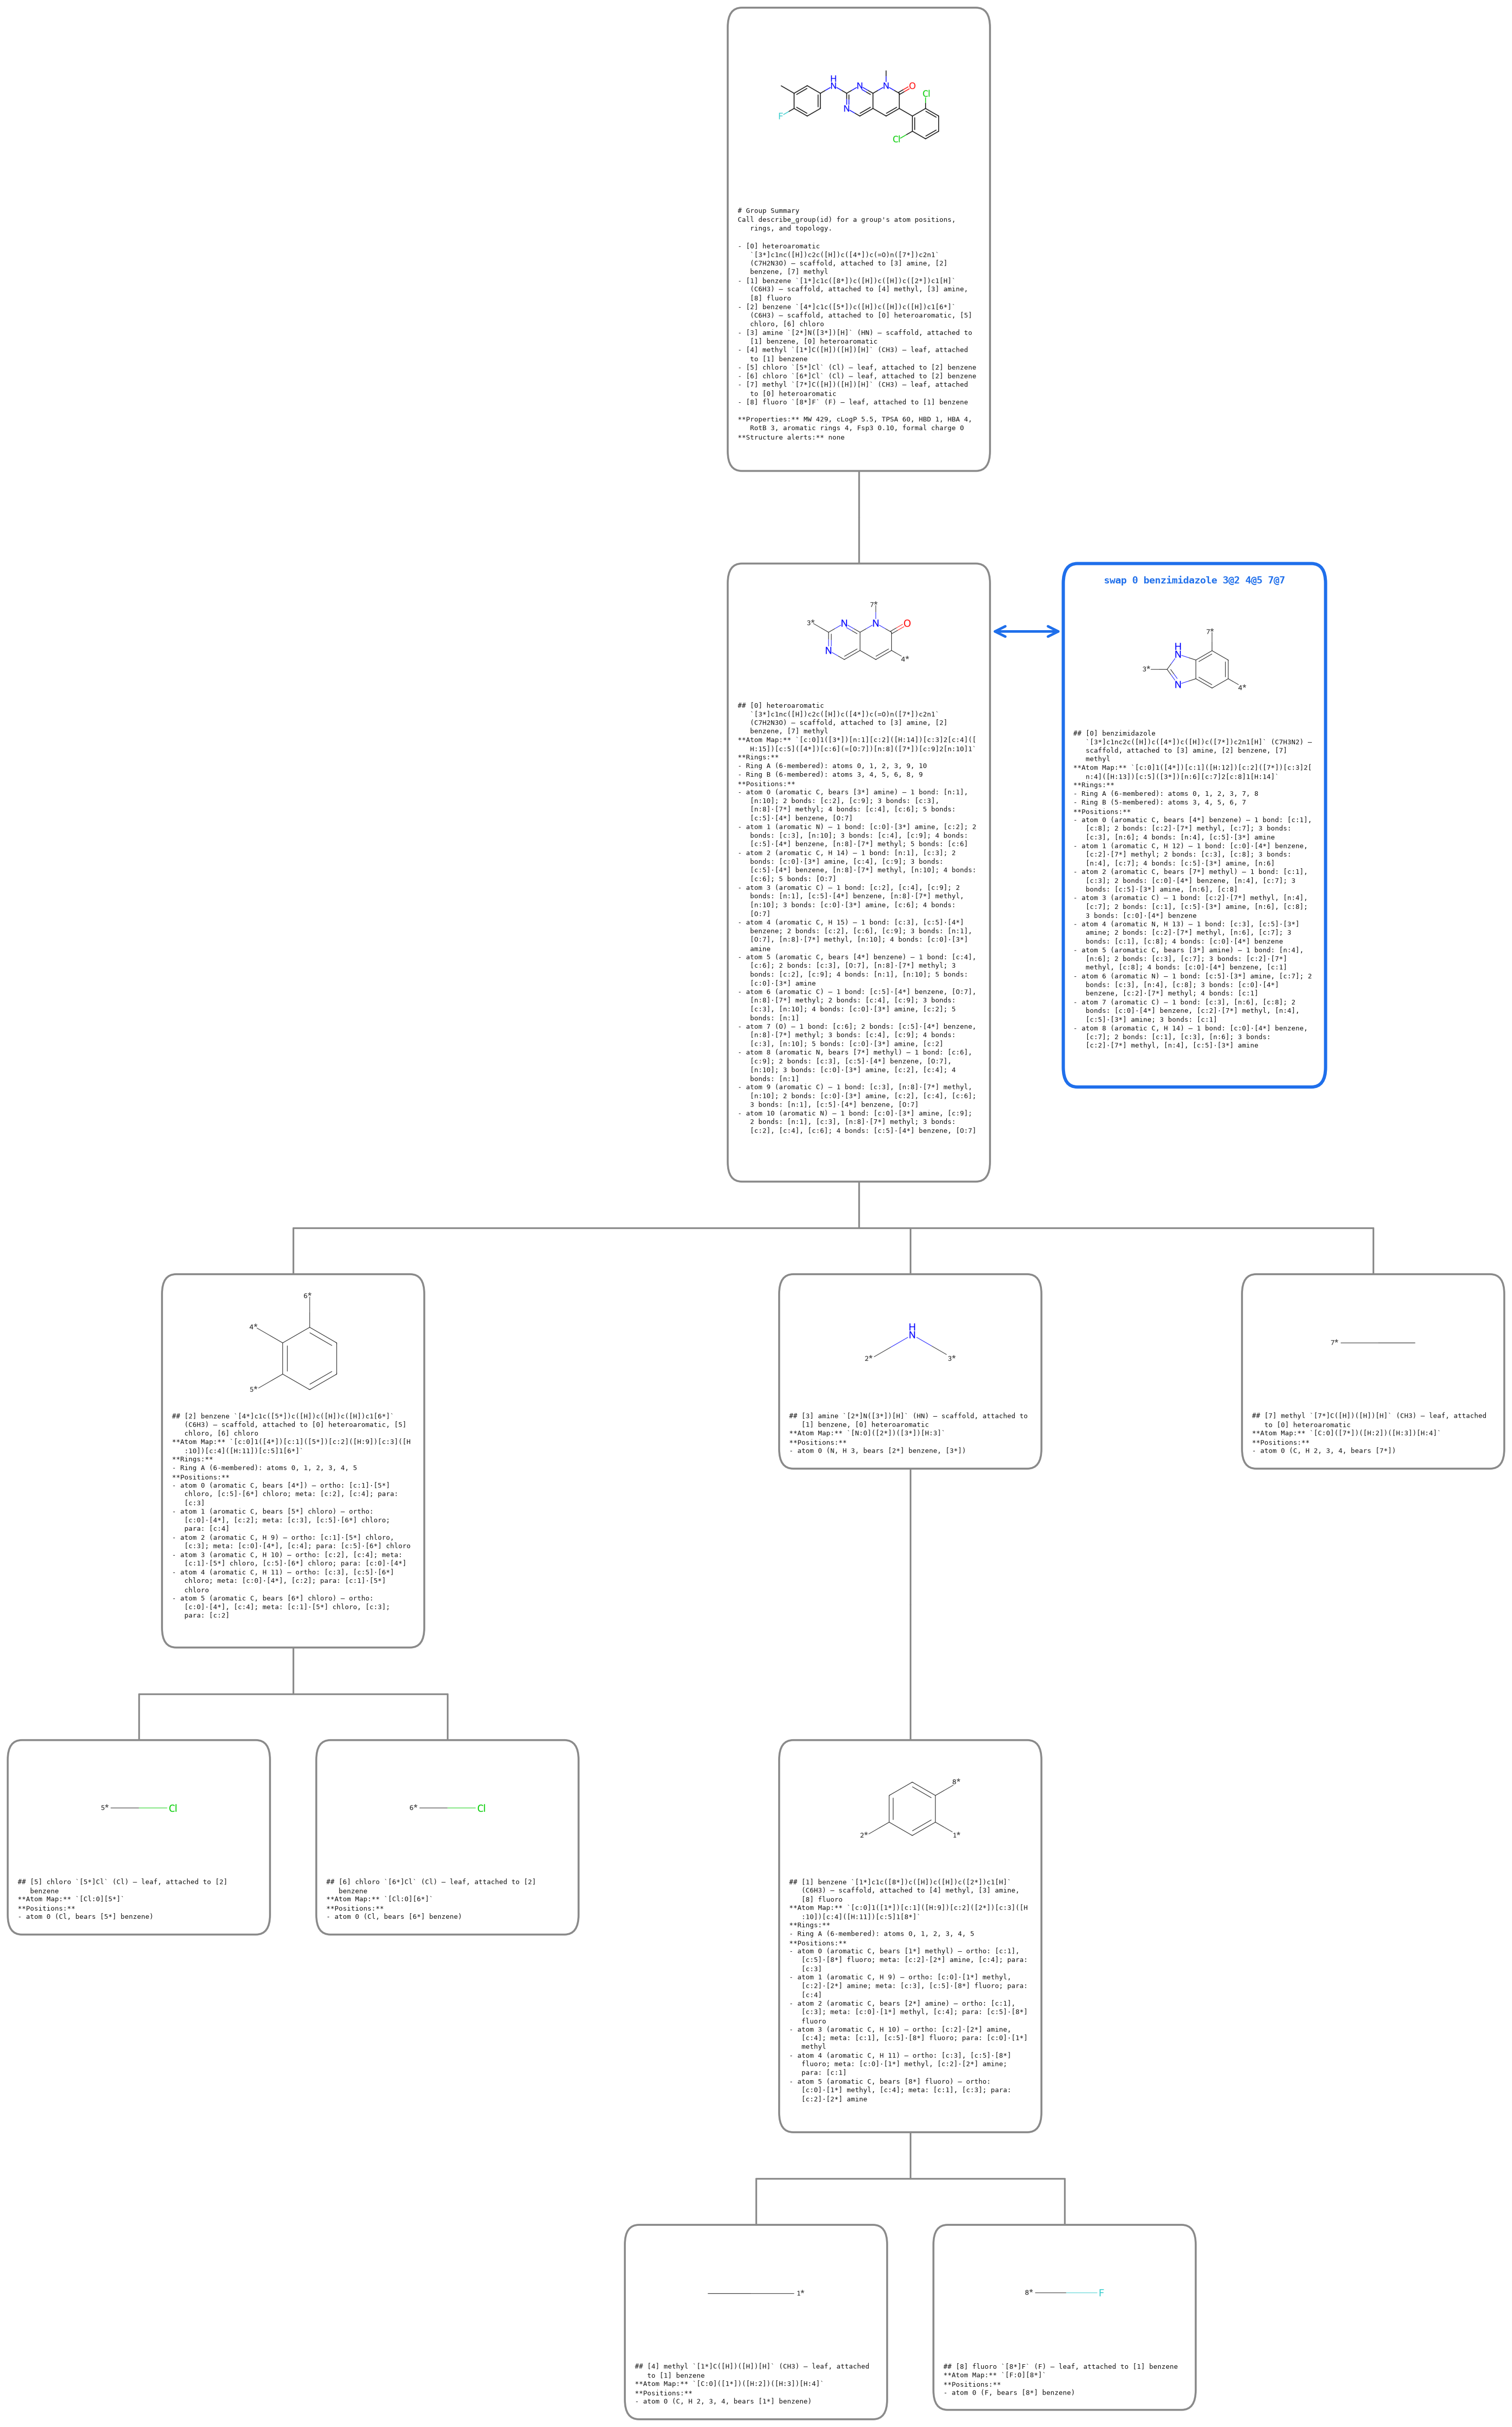

In [3]:
# ---- sizes (inches) ----
W, STRUCT, ROOT_STRUCT = 3.4, 1.5, 2.3
FONT, LINE_H, WRAP, TITLE_H = 6.0, 0.122, 58, 0.36
PADX, PADY, GAPY_IN = 0.13, 0.13, 0.15
HGAP, VGAP, MARG, ARROW_GAP = 0.60, 1.20, 0.40, 0.95
BLUE, EDGE, TXT = '#1f6feb', '#8a8a8a', '#111111'
CARD_LW, BLUE_LW, LINK_LW = 1.8, 3.0, 1.6
LINESP = 1.35

def wrapped(text):
    out = []
    for ln in text.split('\n'):
        out += textwrap.wrap(ln, WRAP, break_long_words=True,
                             break_on_hyphens=False, subsequent_indent='   ') or ['']
    return '\n'.join(out)

def prep(n, root=False, titled=False):
    n['wrapped'] = wrapped(n['text'])
    n['sstruct'] = ROOT_STRUCT if root else STRUCT
    n['title_h'] = TITLE_H if titled else 0.0
    nl = n['wrapped'].count('\n') + 1
    n['h'] = n['title_h'] + PADY + n['sstruct'] + GAPY_IN + nl * LINE_H + PADY

depth = {}
def set_depth(k, d):
    depth[k] = d
    for c in child_of.get(k, []):
        set_depth(c, d + 1)
set_depth('mol', 0)
for k in nodes:
    prep(nodes[k], root=(k == 'mol'))
prep(swap_panel, titled=True)

# tidy x: leaves left-to-right, parents centred over their children
xpos, counter = {}, [0]
def assign_x(k):
    cs = child_of.get(k, [])
    if not cs:
        xpos[k] = counter[0]; counter[0] += 1
    else:
        for c in cs: assign_x(c)
        xpos[k] = sum(xpos[c] for c in cs) / len(cs)
assign_x('mol')

# centre the whole figure about the root, so the tree reads balanced and the
# swap panel sits in the level-2 whitespace to the core's right
base = lambda k: xpos[k] * (W + HGAP)
root_c = base('mol') + W / 2
swap_base = base(core_id) + W + ARROW_GAP
max_r = max(max(base(k) + W for k in nodes), swap_base + W)
half = max(root_c, max_r - root_c)
figW = 2 * half + 2 * MARG
XSHIFT = MARG + half - root_c

band_h = {}
for k in nodes:
    band_h[depth[k]] = max(band_h.get(depth[k], 0), nodes[k]['h'])
band_h[depth[core_id]] = max(band_h[depth[core_id]], swap_panel['h'])
ytop, acc = {}, MARG
for d in sorted(band_h):
    ytop[d] = acc; acc += band_h[d] + VGAP
figH = acc - VGAP + MARG

left = lambda k: base(k) + XSHIFT
cx = lambda k: left(k) + W / 2
swap_left = swap_base + XSHIFT

fig = plt.figure(figsize=(figW, figH), dpi=150)
fig.patch.set_facecolor('white')
fx, fy = 1.0 / figW, 1.0 / figH
def L2(x1, y1, x2, y2, color=EDGE, lw=LINK_LW):
    fig.add_artist(Line2D([x1 * fx, x2 * fx], [y1 * fy, y2 * fy], color=color, lw=lw,
                          solid_capstyle='round', transform=fig.transFigure, zorder=0))

# canonical right-angle (elbow) connectors: parent -> bus -> children
for k in nodes:
    cs = child_of.get(k, [])
    if not cs:
        continue
    pby = figH - (ytop[depth[k]] + nodes[k]['h'])   # parent bottom
    cty = figH - ytop[depth[cs[0]]]                 # children top (same depth)
    ymid = (pby + cty) / 2
    L2(cx(k), pby, cx(k), ymid)
    xs = [cx(c) for c in cs]
    if len(cs) > 1:
        L2(min(xs), ymid, max(xs), ymid)
    for c in cs:
        L2(cx(c), ymid, cx(c), cty)

def draw_card(Lx, top, n, edge, lw):
    bottom = figH - (top + n['h'])
    fig.add_artist(FancyBboxPatch((Lx * fx, bottom * fy), W * fx, n['h'] * fy,
                   boxstyle='round,pad=0,rounding_size=0.008', linewidth=lw,
                   edgecolor=edge, facecolor='white', transform=fig.transFigure, zorder=1))
    if n.get('title'):
        fig.text((Lx + W / 2) * fx, (figH - (top + n['title_h'] * 0.62)) * fy, n['title'],
                 ha='center', va='center', fontsize=9, family='monospace', fontweight='bold',
                 color=edge, zorder=3)
    s = n['sstruct']
    sb = top + n['title_h'] + PADY
    axs = fig.add_axes([(Lx + (W - s) / 2) * fx, (figH - sb - s) * fy, s * fx, s * fy], zorder=2)
    axs.imshow(n['img']); axs.axis('off')
    ty = sb + s + GAPY_IN
    th = n['h'] - (n['title_h'] + PADY + s + GAPY_IN + PADY)
    axt = fig.add_axes([(Lx + PADX) * fx, (figH - ty - th) * fy,
                        (W - 2 * PADX) * fx, th * fy], zorder=2)
    axt.axis('off')
    axt.text(0, 1, n['wrapped'], va='top', ha='left', family='monospace', color=TXT,
             fontsize=FONT, linespacing=LINESP, transform=axt.transAxes)
    return sb + s / 2

for k, n in nodes.items():
    draw_card(left(k), ytop[depth[k]], n, EDGE, CARD_LW)

# swap panel + double-headed arrow from the core
core_mid = ytop[depth[core_id]] + PADY + STRUCT / 2
draw_card(swap_left, ytop[depth[core_id]], swap_panel, BLUE, BLUE_LW)
ay = figH - core_mid
fig.add_artist(FancyArrowPatch(((left(core_id) + W) * fx, ay * fy), (swap_left * fx, ay * fy),
               arrowstyle='<->', mutation_scale=24, color=BLUE, lw=2.4,
               transform=fig.transFigure, zorder=3))

OUT = Path.cwd()
if OUT.name != 'notebooks' and (OUT / 'notebooks').is_dir():
    OUT = OUT / 'notebooks'
fig.savefig(OUT / 'representation-figure.png', dpi=150, facecolor='white')
print('saved', OUT / 'representation-figure.png', '|', round(figW, 1), 'x', round(figH, 1), 'in')
plt.show()